In [1]:
import cv2
import os 
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt 

In [2]:
from torchvision import datasets 
import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

PREPROCESSING 

In [3]:
#train 
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.Normalize((0.1307,), (0.3081,))
])

#test 
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

x_train = datasets.MNIST(root='data', train=True, download=True, transform=train_transform)
x_test = datasets.MNIST(root='data', train=False, download=True, transform=test_transform)


loaders={
    'train' : DataLoader(x_train, batch_size=100, shuffle=True,num_workers=1),
    'test' : DataLoader(x_test, batch_size=100, shuffle=True,num_workers=1)
}

print(f'Train dataset size: {len(x_train)}')
print(f'Test dataset size: {len(x_test)}')

Train dataset size: 60000
Test dataset size: 10000


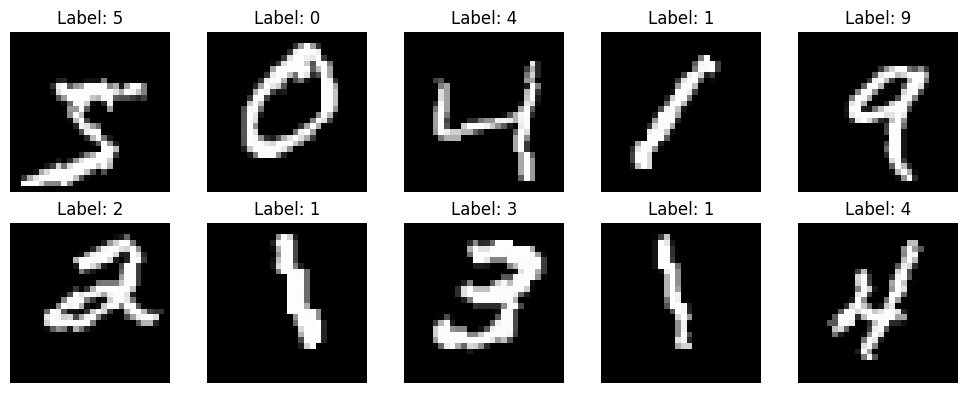

In [4]:
fig,axes =plt.subplots(2,5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
    img, label = x_train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.savefig("plots/sample_images.png", dpi=300, bbox_inches='tight')
plt.show()

MY CNN

In [5]:
class CNN_batchnorm(nn.Module):
    def __init__(self):
        super(CNN_batchnorm, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv2_dropout = nn.Dropout2d()
        self.fc1 = nn.Linear(1024,128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x=F.relu(F.max_pool2d(self.bn1(self.conv1(x)),2))
        x=F.relu(F.max_pool2d(self.conv2_dropout(self.bn2(self.conv2(x))),2))
        x = x.view(-1, 1024)
        x = F.relu(self.fc1(x))
        x=F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)  
    
cnn =CNN_batchnorm()
print(cnn)
print (f'Total parameters: {sum(p.numel() for p in cnn.parameters())}')

CNN_batchnorm(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2_dropout): Dropout2d(p=0.5, inplace=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total parameters: 184778


RESNET 

In [7]:
class resblock(nn.Module):
    def __init__(self,in_ch, out_ch, stride=1):
        super(resblock, self).__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, bias=False, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class resMNIST(nn.Module):
    def __init__(self):
        super(resMNIST, self).__init__()
        self.conv1 = nn.Conv2d(1, 16,3, bias=False, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = resblock(16, 32, stride=2)
        self.layer2 = resblock(32, 64, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.25)
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return F.log_softmax(self.fc(x), dim=1)

resnet = resMNIST()
print(resnet)
print (f'Total parameters: {sum(p.numel() for p in resnet.parameters())}')



resMNIST(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (layer1): resblock(
    (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv2d(16, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (layer2): resblock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_st